# CNN Model

## Objective

In [54]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "GVLiD"
SPLIT_FILE = PROJECT_ROOT / "data" / "processed" / "dataset_split.csv"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Raw data exists:", RAW_DATA_DIR.exists())
print("Split file exists:", SPLIT_FILE.exists())

Raw data exists: True
Split file exists: True


In [ ]:
%pip install tensorflow

## Reproducibility / random seed

## Dataset loading

In [55]:
split_df = pd.read_csv(SPLIT_FILE)

print("Total records:", len(split_df))
display(split_df.head())

Total records: 3477


,Image_ID,image_filename,Vineyard,Disease_Type,Split
0,IMG_0001,black rot001.jpg,Vineyard_22,Black Rot,Validation
1,IMG_0002,black rot002.jpg,Vineyard_28,Black Rot,Train
2,IMG_0003,black rot003.jpg,Vineyard_14,Black Rot,Train
3,IMG_0004,black rot004.jpg,Vineyard_20,Black Rot,Train
4,IMG_0005,black rot005.jpg,Vineyard_8,Black Rot,Validation


In [56]:
print(split_df["Disease_Type"].value_counts())

Disease_Type
Healthy        1109
Esca            888
Black Rot       809
Leaf Blight     671
Name: count, dtype: int64


In [57]:
CLASS_NAMES = [
    "Black Rot",
    "Esca",
    "Healthy",
    "Leaf Blight"
]

LABEL_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

split_df["label"] = split_df["Disease_Type"].map(LABEL_TO_INDEX)

print(LABEL_TO_INDEX)
print("Missing labels:", split_df["label"].isna().sum())

{'Black Rot': 0, 'Esca': 1, 'Healthy': 2, 'Leaf Blight': 3}
Missing labels: 0


In [58]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

image_paths = [
    path
    for path in RAW_DATA_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Images found:", len(image_paths))

Images found: 6954


In [59]:
filename_to_path = {}
duplicate_filenames = []

for path in image_paths:
    if path.name in filename_to_path:
        duplicate_filenames.append(path.name)
    else:
        filename_to_path[path.name] = path

print("Unique filenames:", len(filename_to_path))
print("Duplicate filenames:", len(duplicate_filenames))

Unique filenames: 3477
Duplicate filenames: 3477


In [60]:
split_df["image_path"] = split_df["image_filename"].map(filename_to_path)

print("CSV records:", len(split_df))
print("Missing image files:", split_df["image_path"].isna().sum())

CSV records: 3477
Missing image files: 0


In [61]:
print(split_df["Split"].value_counts())

Split
Train         2492
Validation     510
Test           475
Name: count, dtype: int64


In [62]:
display(
    pd.crosstab(
        split_df["Split"],
        split_df["Disease_Type"]
    )
)

Disease_Type,Black Rot,Esca,Healthy,Leaf Blight
Split,,,,
Test,120,124,144,87
Train,560,631,807,494
Validation,129,133,158,90


In [64]:
train_df = split_df[split_df["Split"] == "Train"].copy()
val_df = split_df[split_df["Split"] == "Validation"].copy()
test_df = split_df[split_df["Split"] == "Test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2492
Validation: 510
Test: 475


## Preprocessing

In [65]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (128, 128)
Batch size: 32


In [66]:
def load_and_preprocess_image(path, label):
    # Read image from disk
    image = tf.io.read_file(path)

    # Decode as RGB
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Tell TensorFlow that the image has 3 channels
    image.set_shape([None, None, 3])

    # Resize to 128 x 128
    image = tf.image.resize(image, IMG_SIZE)

    # Convert pixel values from 0-255 to 0-1
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [67]:
def make_dataset(df, training=False):
    paths = df["image_path"].astype(str).values
    labels = df["label"].astype("int32").values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    # Shuffle training images only
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    # Load and preprocess images
    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Group images into batches
    dataset = dataset.batch(BATCH_SIZE)

    # Prepare following batches while model is running
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [68]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("TensorFlow datasets created.")

TensorFlow datasets created.


In [69]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel minimum:", images.numpy().min())
    print("Pixel maximum:", images.numpy().max())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


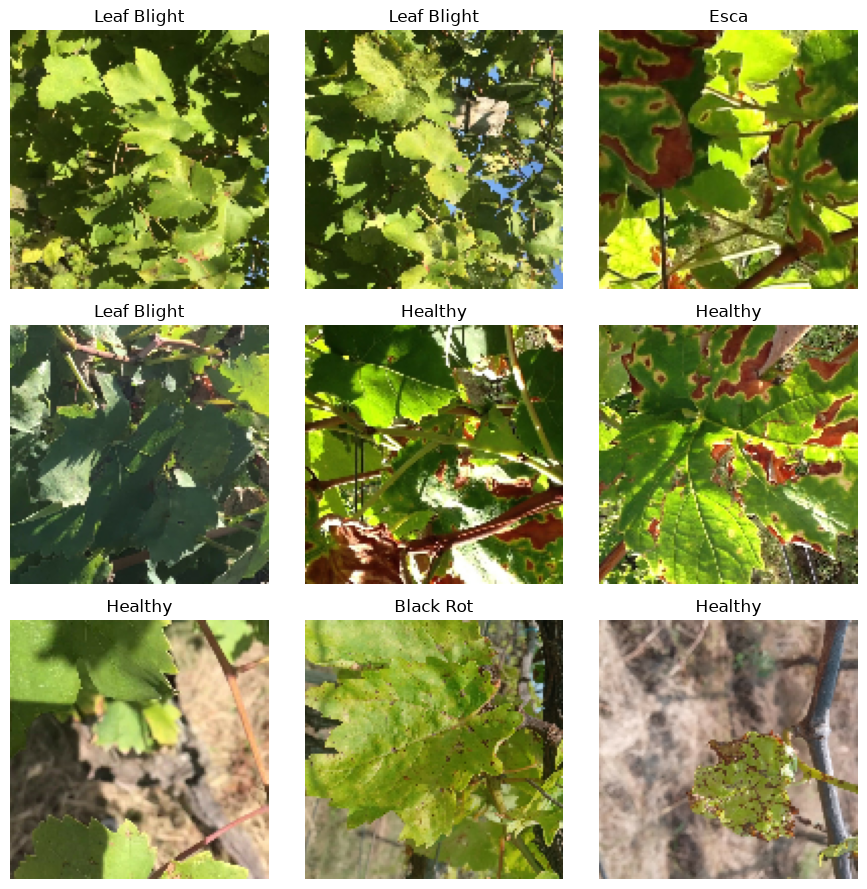

In [70]:
plt.figure(figsize=(9, 9))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        label_index = int(labels[i].numpy())
        plt.title(CLASS_NAMES[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
def class_from_filename(filename):
    name = filename.lower().strip()

    if name.startswith("black rot"):
        return "Black Rot"
    elif name.startswith("esca"):
        return "Esca"
    elif name.startswith("healthy"):
        return "Healthy"
    elif name.startswith("leaf blight"):
        return "Leaf Blight"
    else:
        return None

split_df["Filename_Class"] = split_df["image_filename"].apply(class_from_filename)

print(split_df["Filename_Class"].value_counts())
print("Unknown filename labels:", split_df["Filename_Class"].isna().sum())

Filename_Class
Healthy        1109
Esca            888
Black Rot       807
Leaf Blight     672
Name: count, dtype: int64
Unknown filename labels: 1


In [72]:
split_df["label_agreement"] = (
    split_df["Filename_Class"] == split_df["Disease_Type"]
)

print(split_df["label_agreement"].value_counts())

print(
    pd.crosstab(
        split_df["Filename_Class"],
        split_df["Disease_Type"]
    )
)

label_agreement
True     2132
False    1345
Name: count, dtype: int64
Disease_Type    Black Rot  Esca  Healthy  Leaf Blight
Filename_Class                                       
Black Rot             807     0        0            0
Esca                    1   887        0            0
Healthy                 0     0      438          671
Leaf Blight             0     1      671            0


In [73]:
FILENAME_LABEL_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

split_df["filename_label"] = (
    split_df["Filename_Class"]
    .map(FILENAME_LABEL_TO_INDEX)
)

In [74]:
def make_filename_dataset(df):
    paths = df["image_path"].astype(str).values
    labels = df["filename_label"].astype("int32").values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.shuffle(
        buffer_size=len(df),
        seed=RANDOM_SEED
    )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    return dataset

In [76]:
filename_train_df = split_df[
    (split_df["Split"] == "Train")
    & split_df["filename_label"].notna()
    & split_df["image_path"].notna()
].copy()

print("Filename-labelled training images:", len(filename_train_df))

Filename-labelled training images: 2491


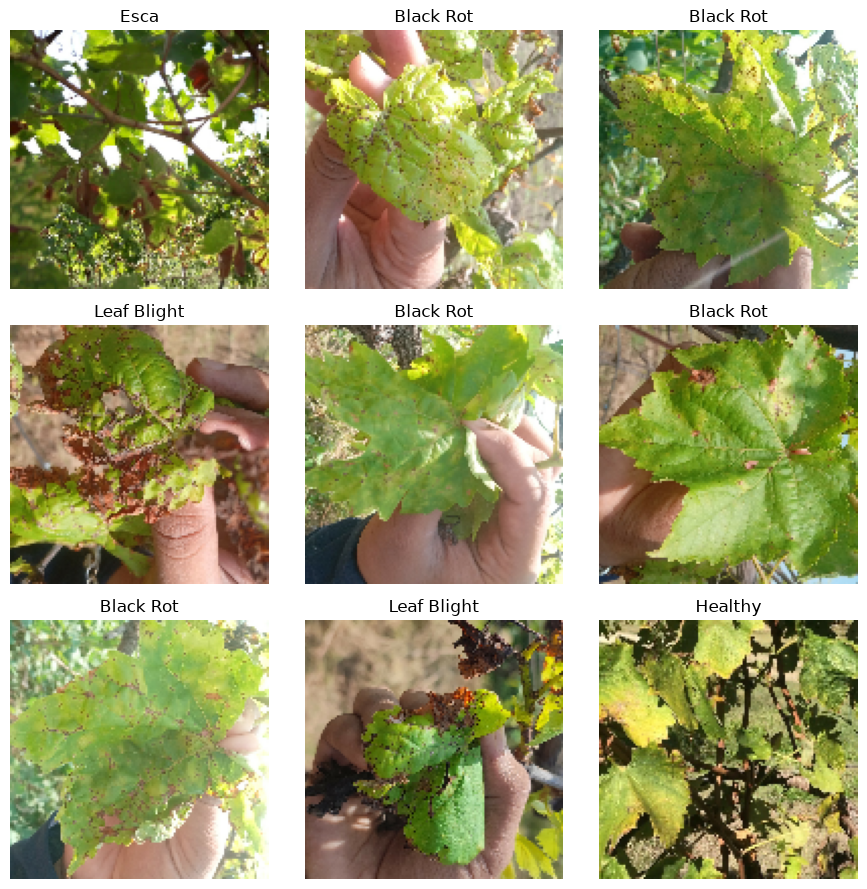

In [77]:
filename_train_ds = make_filename_dataset(filename_train_df)

plt.figure(figsize=(9, 9))

for images, labels in filename_train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        label_index = int(labels[i].numpy())
        plt.title(CLASS_NAMES[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [78]:
split_df["filename_label"] = (
    split_df["Filename_Class"]
    .map(LABEL_TO_INDEX)
)

print("Missing filename labels:", split_df["filename_label"].isna().sum())

Missing filename labels: 1


In [79]:
filename_train_df = split_df[
    (split_df["Split"] == "Train")
    & split_df["filename_label"].notna()
].copy()

print("Filename-labelled training images:", len(filename_train_df))

Filename-labelled training images: 2491


In [80]:
filename_train_ds = make_filename_dataset(filename_train_df)

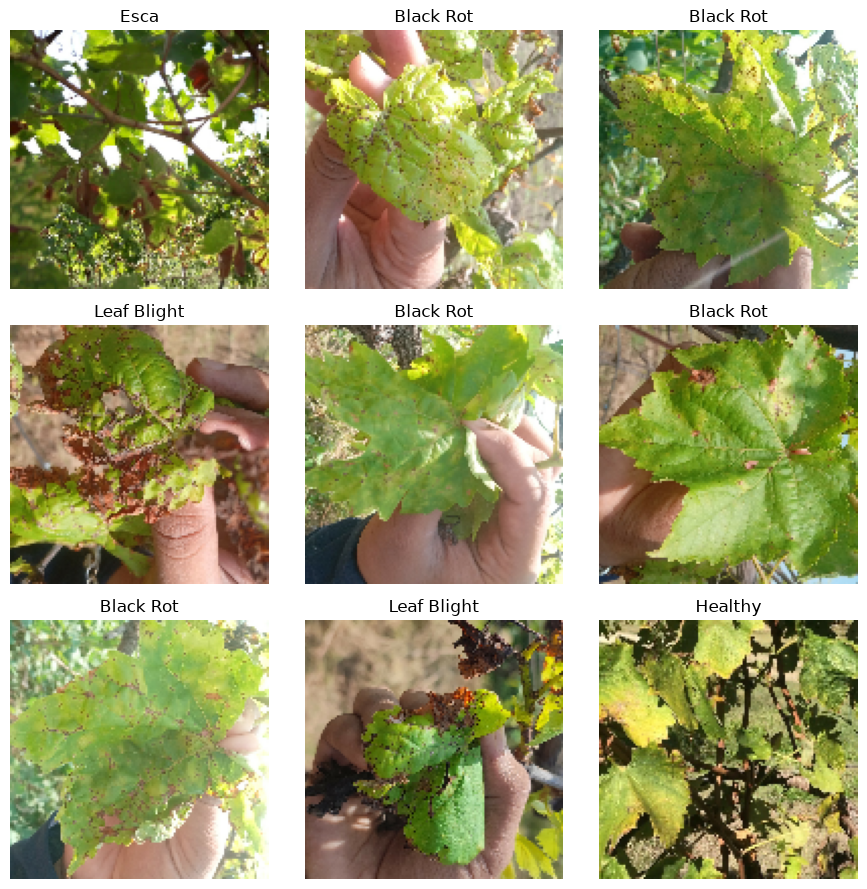

In [81]:
plt.figure(figsize=(9, 9))

for images, labels in filename_train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        label_index = int(labels[i].numpy())
        plt.title(CLASS_NAMES[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

Mismatched images: 1344


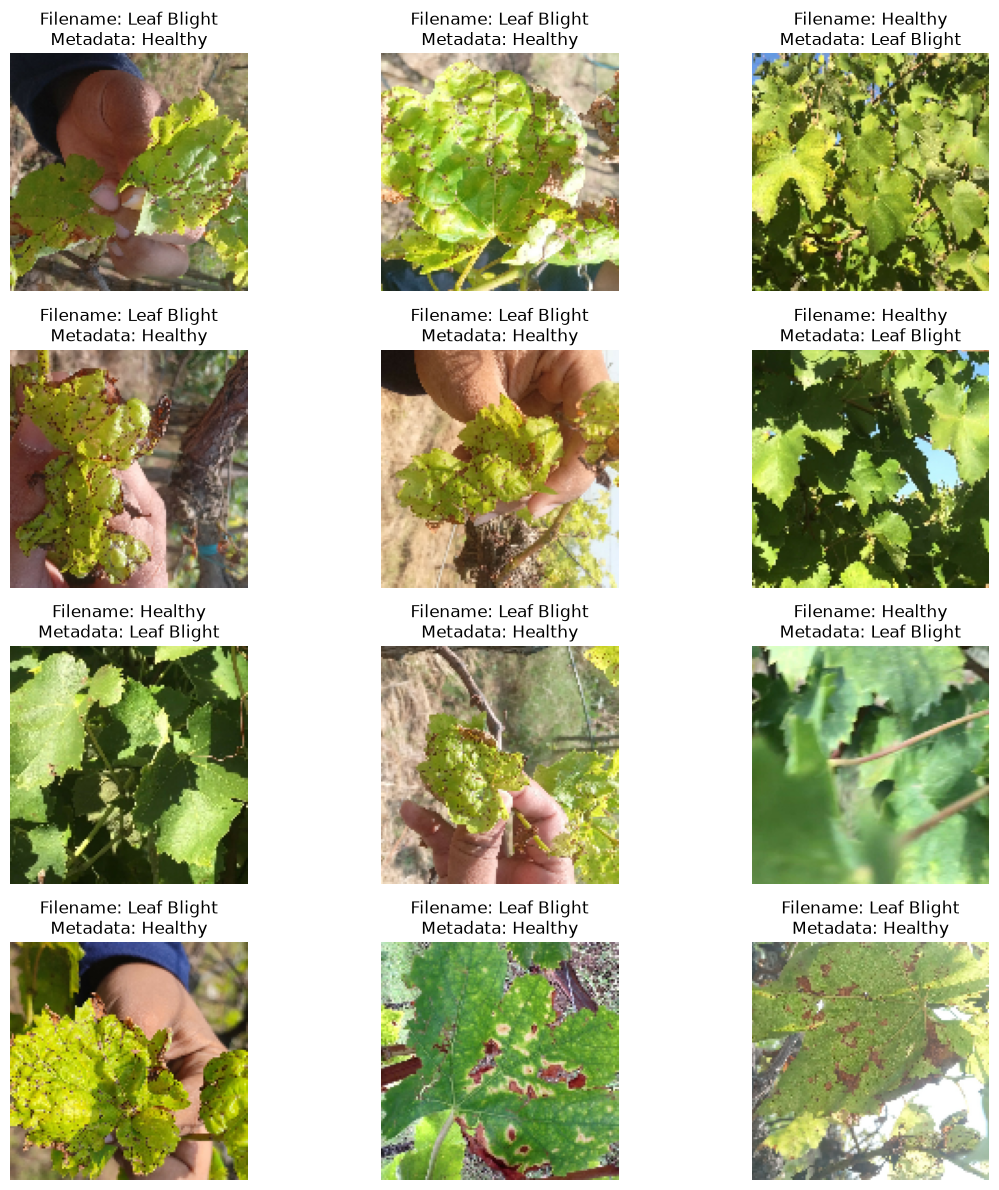

In [82]:
mismatch_df = split_df[
    (split_df["Filename_Class"].notna())
    & (split_df["Filename_Class"] != split_df["Disease_Type"])
].copy()

print("Mismatched images:", len(mismatch_df))

sample = mismatch_df.sample(
    n=12,
    random_state=RANDOM_SEED
)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample.iterrows()):
    image = tf.io.read_file(str(row["image_path"]))
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    plt.subplot(4, 3, i + 1)
    plt.imshow(image.numpy())

    plt.title(
        f"Filename: {row['Filename_Class']}\n"
        f"Metadata: {row['Disease_Type']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [83]:
FOLDER_TO_CLASS = {
    "Black rot": "Black Rot",
    "esca": "Esca",
    "healthy": "Healthy",
    "leaf blight": "Leaf Blight"
}

split_df["Target_Class"] = split_df["image_path"].apply(
    lambda path: FOLDER_TO_CLASS[path.parent.name]
)

# Replace the modelling label with the folder-derived class
split_df["label"] = split_df["Target_Class"].map(LABEL_TO_INDEX)

print(split_df["Target_Class"].value_counts())
print("\nMissing target labels:", split_df["label"].isna().sum())

Target_Class
Healthy        1109
Esca            888
Black Rot       808
Leaf Blight     672
Name: count, dtype: int64

Missing target labels: 0


In [84]:
comparison = pd.crosstab(
    split_df["Target_Class"],
    split_df["Disease_Type"]
)

display(comparison)

agreement = (
    split_df["Target_Class"] == split_df["Disease_Type"]
)

print("Labels agree:", agreement.sum())
print("Labels disagree:", (~agreement).sum())
print(
    "Agreement percentage:",
    round(agreement.mean() * 100, 2),
    "%"
)

Disease_Type,Black Rot,Esca,Healthy,Leaf Blight
Target_Class,,,,
Black Rot,808,0,0,0
Esca,1,887,0,0
Healthy,0,0,438,671
Leaf Blight,0,1,671,0


Labels agree: 2133
Labels disagree: 1344
Agreement percentage: 61.35 %


In [85]:
print("Overall target distribution:")
print(split_df["Target_Class"].value_counts())

print("\nTarget distribution by split:")

display(
    pd.crosstab(
        split_df["Split"],
        split_df["Target_Class"]
    )
)

Overall target distribution:
Target_Class
Healthy        1109
Esca            888
Black Rot       808
Leaf Blight     672
Name: count, dtype: int64

Target distribution by split:


Target_Class,Black Rot,Esca,Healthy,Leaf Blight
Split,,,,
Test,120,124,153,78
Train,559,631,802,500
Validation,129,133,154,94


In [86]:
train_df = split_df[
    split_df["Split"] == "Train"
].copy()

val_df = split_df[
    split_df["Split"] == "Validation"
].copy()

test_df = split_df[
    split_df["Split"] == "Test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2492
Validation: 510
Test: 475


In [87]:
train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df
)

test_ds = make_dataset(
    test_df
)

print("Datasets recreated with folder-derived target labels.")

Datasets recreated with folder-derived target labels.


In [88]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Labels in batch:", labels.numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels in batch: [0 1 3 1 1 0 1 3 1 0 1 2 1 0 2 3 2 2 2 0 2 1 3 1 0 2 2 1 2 2 1 3]


### Label-quality decision

A systematic disagreement was identified between the `Disease_Type` metadata and the dataset's folder/filename class labels, particularly for Healthy and Leaf Blight. Visual inspection of mismatched examples suggested that folder/filename labels were more consistent with the apparent image content. Therefore, folder membership was used as the provisional target label for modelling, while the original `Disease_Type` metadata was retained for traceability.

## CNN architecture

In [89]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
], name="data_augmentation")

In [90]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Convolutional block 1
    tf.keras.layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolutional block 2
    tf.keras.layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolutional block 3
    tf.keras.layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Summarise learned feature maps
    tf.keras.layers.GlobalAveragePooling2D(),

    # Regularisation
    tf.keras.layers.Dropout(0.3),

    # Dense classification layer
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    # Output layer: 4 classes
    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

In [91]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

## Compilation

In [92]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training

In [93]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=RESULTS_DIR / "cnn_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [94]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


/home/chetan/miniforge3/envs/research/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1789460382.465586   14107 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.
W0000 00:00:1789460382.711904   14107 cpu_allocator_impl.cc:82] Allocation of 33554432 exceeds 10% of free system memory.
W0000 00:00:1789460382.965286   14107 cpu_allocator_impl.cc:82] Allocation of 23592960 exceeds 10% of free system memory.
W0000 00:00:1789460383.168027   14110 cpu_allocator_impl.cc:82] Allocation of 33554432 exceeds 10% of free system memory.
W0000 00:00:1789460383.245099   14108 cpu_allocator_impl.cc:82] Allocation of 28311552 exceeds 10% of free system memory.


78/78 ━━━━━━━━━━━━━━━━━━━━ 70s 843ms/step - accuracy: 0.3764 - loss: 1.2956 - val_accuracy: 0.5353 - val_loss: 1.1808 - learning_rate: 0.0010
Epoch 2/25
78/78 ━━━━━━━━━━━━━━━━━━━━ 77s 982ms/step - accuracy: 0.6136 - loss: 0.9451 - val_accuracy: 0.6020 - val_loss: 0.9404 - learning_rate: 0.0010
Epoch 3/25
78/78 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6589 - loss: 0.7884 - val_accuracy: 0.5745 - val_loss: 0.9964 - learning_rate: 0.0010
Epoch 4/25
78/78 ━━━━━━━━━━━━━━━━━━━━ 78s 995ms/step - accuracy: 0.7059 - loss: 0.6969 - val_accuracy: 0.5922 - val_loss: 0.9600 - learning_rate: 0.0010
Epoch 5/25
78/78 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7295 - loss: 0.6411 - val_accuracy: 0.7333 - val_loss: 0.6691 - learning_rate: 5.0000e-04
Epoch 6/25
78/78 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7424 - loss: 0.6118 - val_accuracy: 0.7137 - val_loss: 0.6960 - learning_rate: 5.0000e-04
Epoch 7/25
78/78 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7476 - loss: 0.5964 - val_acc

## Training history

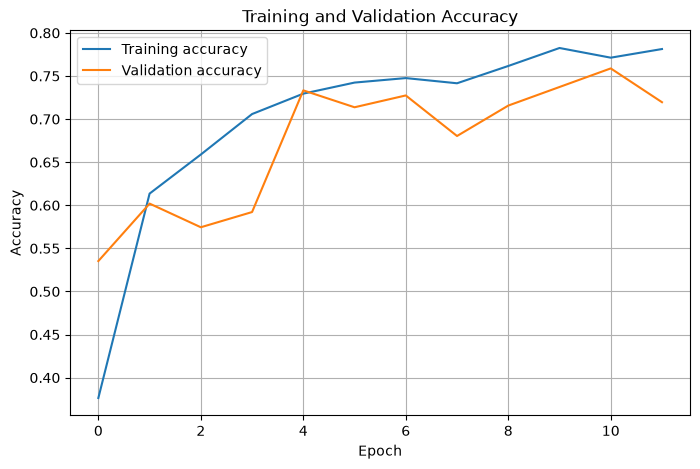

In [95]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

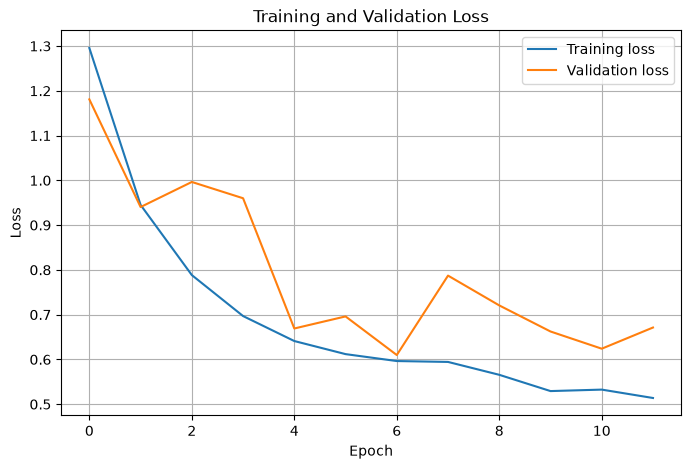

In [96]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## Save model/results

In [97]:
model.save(RESULTS_DIR / "cnn_final.keras")

print("Final model saved to:")
print(RESULTS_DIR / "cnn_final.keras")

Final model saved to:
/home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_final.keras


In [98]:
import pickle

HISTORY_PATH = RESULTS_DIR / "training_history.pkl"

with open(HISTORY_PATH, "wb") as f:
    pickle.dump(history.history, f)

print(f"Training history saved to: {HISTORY_PATH}")

Training history saved to: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/training_history.pkl


## Initial observations

The CNN showed strong learning during the first epochs, with both training and validation loss decreasing substantially. Validation loss reached its minimum around epoch 6, after which it began to fluctuate and increase while training loss continued to decline. This indicates the onset of overfitting. Early stopping therefore prevented unnecessary further training and restored the weights from the best validation-loss epoch. The relatively close training and validation accuracies suggest that overfitting remained limited.